In [35]:
import os
import kagglehub
import mlx.core as mlx
import mlx.nn as nn
import mlx.optimizers as optim
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [36]:
path = kagglehub.dataset_download("muhammadrehan00/chest-xray-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/madsfjeldberg/.cache/kagglehub/datasets/muhammadrehan00/chest-xray-dataset/versions/1


In [37]:
for folder in ["train", "test", "val"]:
    print(f"Contents of {folder} folder:")
    for subfolder in ["NORMAL", "PNEUMONIA"]:
        subfolder_path = f"{path}/{folder}/{subfolder}"
        print(f"  {subfolder}:")
        for filename in os.listdir(subfolder_path)[:5]:  # Show first 5 files
            print(f"    {filename}")

Contents of train folder:
  NORMAL:
    normal-2125.jpg
    normal-4554.jpg
    normal-5892.jpg
    normal-6343.jpg
    normal-6425.jpg
  PNEUMONIA:
    pneumonia-1180.jpg
    pneumonia-3797.jpg
    pneumonia-2489.jpg
    pneumonia-4946.jpg
    pneumonia-839.jpg
Contents of test folder:
  NORMAL:
    normal-549.jpg
    normal-207.jpg
    normal-561.jpg
    normal-575.jpg
    normal-213.jpg
  PNEUMONIA:
    pneumonia-193.jpg
    pneumonia-187.jpg
    pneumonia-150.jpg
    pneumonia-144.jpg
    pneumonia-178.jpg
Contents of val folder:
  NORMAL:
    normal-9070.jpg
    normal-8408.jpg
    normal-9064.jpg
    normal-8352.jpg
    normal-8434.jpg
  PNEUMONIA:
    pneumonia-5480.jpg
    pneumonia-5494.jpg
    pneumonia-5325.jpg
    pneumonia-5443.jpg
    pneumonia-5457.jpg


Saved 100 normalized images
Saved 200 normalized images
Saved 300 normalized images
Saved 400 normalized images
Saved 500 normalized images
Saved 600 normalized images
Saved 700 normalized images
Saved 800 normalized images
Saved 900 normalized images
Saved 1000 normalized images
Saved 1100 normalized images
Saved 1200 normalized images
Saved 1300 normalized images
Saved 1400 normalized images
Saved 1500 normalized images
Saved 1600 normalized images
Saved 1700 normalized images
Saved 1800 normalized images
Saved 1900 normalized images
Saved 2000 normalized images
Saved 2100 normalized images
Saved 2200 normalized images
Saved 2300 normalized images
Saved 2400 normalized images
Saved 2500 normalized images
Saved 2600 normalized images
Saved 2700 normalized images
Saved 2800 normalized images
Saved 2900 normalized images
Saved 3000 normalized images
Saved 3100 normalized images
Saved 3200 normalized images
Saved 3300 normalized images
Saved 3400 normalized images
Saved 3500 normalized i

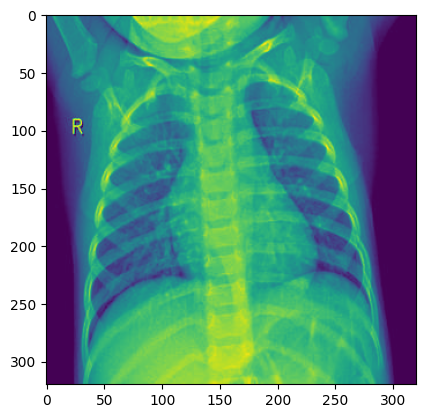

In [38]:
import util

# Normalize and save images locally to ./normalized_images
util.normalize_and_save_images(path, output_path="./normalized_images")

plt.imshow(Image.open("./normalized_images/train/NORMAL/normal-929.jpg"))

# Set path to the normalized images for further processing
path = "./normalized_images"

In [39]:
# Load the dataset
X_train, y_train = util.load_dataset(path, "train")
X_val, y_val = util.load_dataset(path, "val")
# load the test set later to avoid unnecessary memory usage during development
# X_test, y_test = util.load_dataset(path, "test")

# NOTE - max_features and max_depth have been set low to avoid long training times during development. These can be increased later for better performance.

In [40]:
import importlib
from sklearn.tree import DecisionTreeClassifier
import models.decisionTree as decisionTree

# Ensure latest decisionTree.py is loaded in kernel
importlib.reload(decisionTree)

dt = DecisionTreeClassifier(max_depth=10, 
                            max_features="sqrt", 
                            splitter="random", 
                            random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Run decision tree classifier
decisionTree.run_validate(dt, X_train, y_train, X_val, y_val)

X_train shape: (11937, 1, 320, 320)
X_val shape: (1470, 1, 320, 320)
Training Decision Tree classifier...
Decision Tree accuracy: 0.8435  (84.35 %)
Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       900
           1       0.76      0.88      0.81       570

    accuracy                           0.84      1470
   macro avg       0.84      0.85      0.84      1470
weighted avg       0.85      0.84      0.85      1470



In [41]:

from sklearn.ensemble import RandomForestClassifier
import models.randomForest as randomForest

rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42, n_jobs=-1)

randomForest.run_validate(rf, X_train, y_train, X_val, y_val)


Training Random Forest classifier...
Random Forest accuracy: 0.8721  (87.21 %)
Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       900
           1       0.78      0.94      0.85       570

    accuracy                           0.87      1470
   macro avg       0.87      0.89      0.87      1470
weighted avg       0.89      0.87      0.87      1470

Confusion Matrix:
[[744 156]
 [ 32 538]]
